#  BigMart Sales EDA

## Problem Statement
Performed Exploratory Data Analysis on BigMart sales data 
to understand product performance, outlet types, 
and customer buying patterns.

## Dataset
- Total Records: 8523
- Total Features: 12
- Source: Kaggle — BigMart Sales Data

## Goals
- Handle missing values and data inconsistencies
- Analyze product and outlet performance
- Detect outliers using IQR method
- Create new features from existing data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [2]:
df2 = pd.read_csv("Train.csv.csv")

In [3]:
df2.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
df2.shape

(8523, 12)

In [6]:
df2.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [7]:
df2['Item_Weight'] = df2['Item_Weight'].fillna(df2['Item_Weight'].mean())

In [8]:
df2['Item_Weight']

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

In [9]:
df2.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [10]:
df2['Outlet_Size'] = df2['Outlet_Size'].fillna(df2['Outlet_Size'].mode()[0])

In [11]:
df2.duplicated().sum()

np.int64(0)

In [12]:
df2['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [13]:
df2['Item_Fat_Content'] = df2['Item_Fat_Content'].replace({'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'})

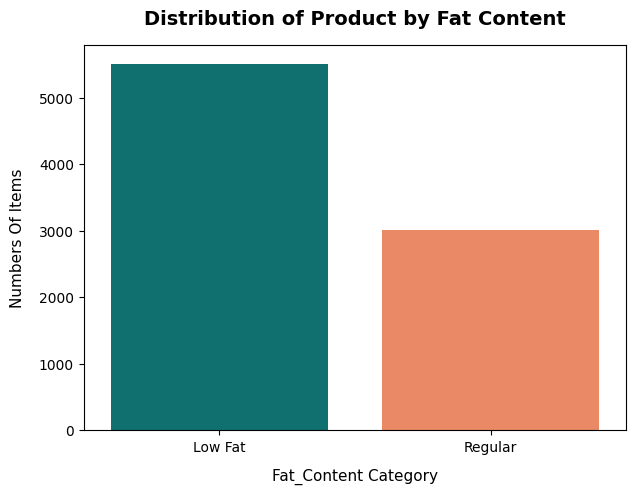

In [15]:
plt.figure(figsize=(7,5))
item_colors = {'Low Fat':'teal', 'Regular':'coral'}
sns.countplot(x='Item_Fat_Content', data=df2,hue='Item_Fat_Content', palette=item_colors, legend=False)
plt.title('Distribution of Product by Fat Content',fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fat_Content Category', fontsize=11, labelpad=10)
plt.ylabel('Numbers Of Items',fontsize=11, labelpad=10)

plt.show()

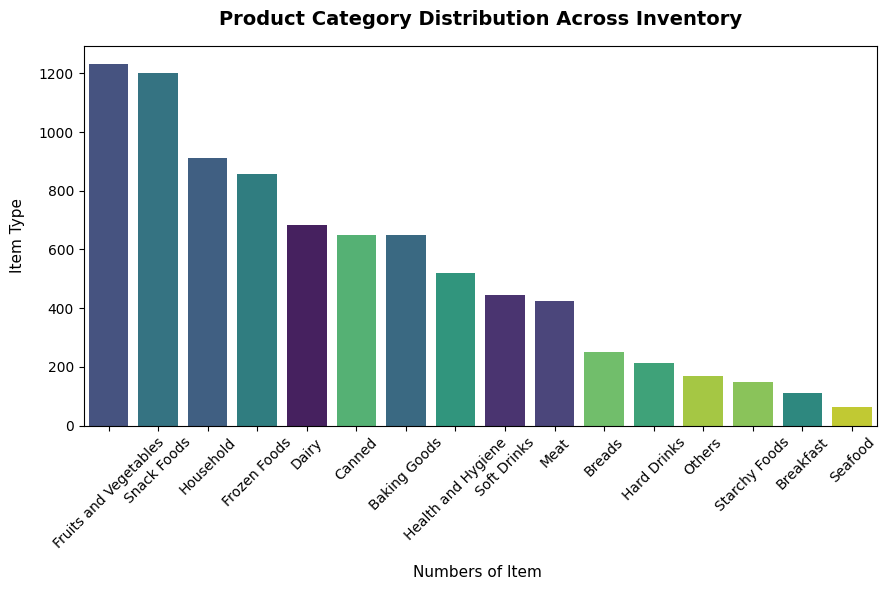

In [17]:
plt.figure(figsize=(9,6))
sns.countplot(x='Item_Type', data=df2, order=df2['Item_Type'].value_counts().index, 
              hue='Item_Type',palette='viridis',legend=False)


plt.title('Product Category Distribution Across Inventory',fontsize=14,fontweight='bold',pad=15)
plt.xlabel('Numbers of Item ',fontsize=11,labelpad=10)
plt.ylabel('Item Type',fontsize=11,labelpad=10)
plt.xticks(rotation = 45, fontsize= 10)
plt.tight_layout()
plt.show()


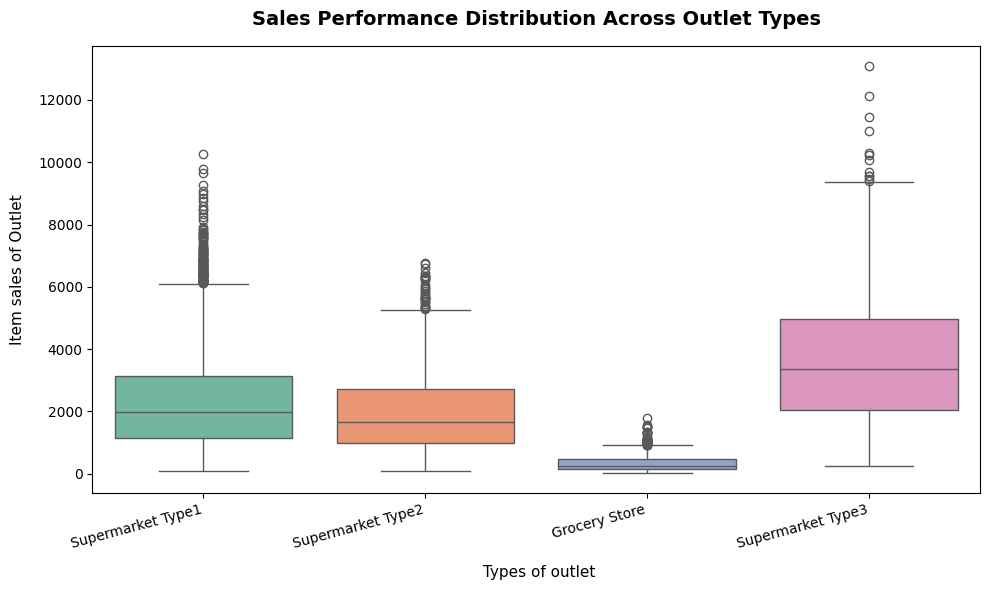

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales',data=df2, hue='Outlet_Type', palette='Set2' , legend=False)
plt.title('Sales Performance Distribution Across Outlet Types',fontsize=14,fontweight='bold',pad=15)
plt.xlabel(' Types of outlet',fontsize=11,labelpad=10)
plt.ylabel('Item sales of Outlet',fontsize=11,labelpad=10)
plt.xticks(rotation=15, fontsize=10, ha='right')
plt.tight_layout()
plt.show()

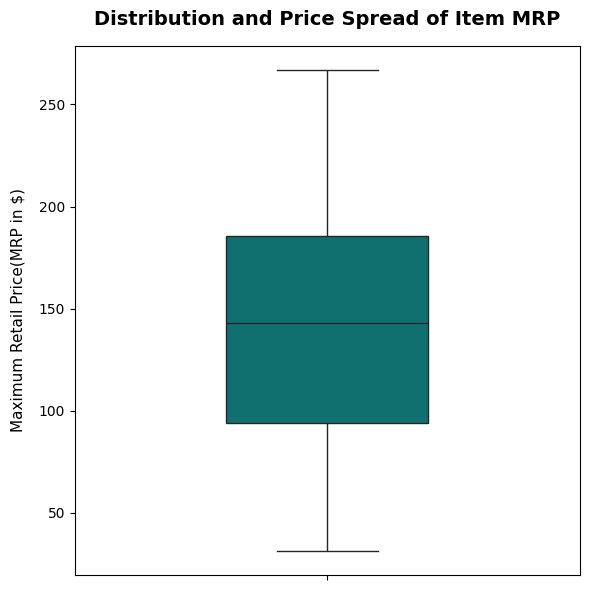

In [19]:
plt.figure(figsize=(6,6))

sns.boxplot(y='Item_MRP', color ='Teal' , data = df2,width=0.4)
plt.title('Distribution and Price Spread of Item MRP',fontsize=14,fontweight='bold', pad=15)
plt.ylabel("Maximum Retail Price(MRP in $)", fontsize=11,labelpad=10)



plt.tight_layout()
plt.show()

In [29]:
Q1 = df2['Item_Outlet_Sales'].quantile(0.25)
Q3 = df2['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1
print(Q1)
print(Q3)
print(IQR)

834.2474
3101.2964
2267.049


In [30]:
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR
print(Lower)
print(Upper)

-2566.3261
6501.8699


In [31]:
outliers = df2[
    (df2['Item_Outlet_Sales'] < Lower) |
    (df2['Item_Outlet_Sales'] > Upper)
]

print(len(outliers))

186


In [34]:
df2['Outlet_year'] = df2['Outlet_Establishment_Year'].apply(lambda x : 2025 - x)

In [35]:
df2.head(5)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_year
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,26
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,16
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,26
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,27
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,38


## Conclusion
- Item_Weight (1463) and Outlet_Size (2410) had missing values
  which were filled using mean and mode respectively
- Item_Fat_Content had inconsistent values (LF, low fat, reg)
  which were standardized to Low Fat and Regular
- Fruits & Vegetables and Snack Foods were the most common 
  product types
- Supermarket Type3 had the highest median sales
- 186 outliers were found in Item_Outlet_Sales using IQR method
- A new feature Outlet_Age was created from Outlet_Establishment_Year